<a href="https://colab.research.google.com/github/kvssri/online-tihiitg/blob/main/Final%20Software%20Package.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# FINAL SOFTWARE PACKAGE & REPORT
# ==========================================

import os
import json
import zipfile
import shutil
import pandas as pd
import numpy as np

print("Final Software Package & Report")
print("================================")
print("Notebook started successfully.")

Final Software Package & Report
Notebook started successfully.


In [2]:
# ==========================================
# STEP 2: UPLOAD FINAL MODEL ARTIFACTS
# ==========================================

from google.colab import files

print("Upload your Final Model Pipeline ZIP file")
print("Example: Final_Model_Pipeline_Freeze_Artifacts.zip")

uploaded = files.upload()

final_zip = list(uploaded.keys())[0]

print("\nUploaded file:")
print(final_zip)

Upload your Final Model Pipeline ZIP file
Example: Final_Model_Pipeline_Freeze_Artifacts.zip


Saving Underwater-Image-Data-set-main.zip to Underwater-Image-Data-set-main.zip

Uploaded file:
Underwater-Image-Data-set-main.zip


In [3]:
# ==========================================
# STEP 3: EXTRACT FINAL MODEL ARTIFACTS
# ==========================================

extract_dir = "/content/final_software_package"

# Remove old folder if it exists
if os.path.exists(extract_dir):
    shutil.rmtree(extract_dir)

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(final_zip, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Files extracted successfully.")
print("\nAvailable files:")

for root, dirs, files_list in os.walk(extract_dir):
    for file in files_list:
        relative_path = os.path.relpath(
            os.path.join(root, file),
            extract_dir
        )
        print("-", relative_path)

Files extracted successfully.

Available files:
- Underwater-Image-Data-set-main/epoch_00100.7z
- Underwater-Image-Data-set-main/README.md
- Underwater-Image-Data-set-main/training_log 2.csv
- Underwater-Image-Data-set-main/epoch_0115.7z
- Underwater-Image-Data-set-main/training_log 4.csv
- Underwater-Image-Data-set-main/epoch_0120.7z
- Underwater-Image-Data-set-main/training_log 6.csv
- Underwater-Image-Data-set-main/training_log 8.csv
- Underwater-Image-Data-set-main/epoch_0135.7z
- Underwater-Image-Data-set-main/epoch_0110.7z
- Underwater-Image-Data-set-main/epoch_0100.7z
- Underwater-Image-Data-set-main/training_log 1.csv
- Underwater-Image-Data-set-main/training_log 5.csv
- Underwater-Image-Data-set-main/epoch_100.7z
- Underwater-Image-Data-set-main/training_log 7.csv
- Underwater-Image-Data-set-main/training_log 3.csv
- Underwater-Image-Data-set-main/epoch_0096.7z


In [4]:
# ==========================================
# STEP 4: CREATE CLEAN REPOSITORY STRUCTURE
# ==========================================

repo_dir = "/content/Final_Underwater_GAN_Project"

# Remove old repository if it exists
if os.path.exists(repo_dir):
    shutil.rmtree(repo_dir)

# Create folders
folders = [
    "model",
    "preprocessing",
    "inference",
    "outputs",
    "figures",
    "results",
    "error_analysis",
    "docs"
]

for folder in folders:
    os.makedirs(os.path.join(repo_dir, folder), exist_ok=True)

print("Clean repository structure created:")
print()

for folder in folders:
    print(f"✓ {folder}/")

print("\nRepository location:")
print(repo_dir)

Clean repository structure created:

✓ model/
✓ preprocessing/
✓ inference/
✓ outputs/
✓ figures/
✓ results/
✓ error_analysis/
✓ docs/

Repository location:
/content/Final_Underwater_GAN_Project


In [5]:
# ==========================================
# STEP 5: ORGANIZE FINAL MODEL FILES
# ==========================================

import glob
import shutil
import os

def find_file(filename):
    matches = glob.glob(
        os.path.join(extract_dir, "**", filename),
        recursive=True
    )
    return matches[0] if matches else None

# Files to organize
file_mapping = {
    "final_tcn_model.pth": "model",
    "final_scaler.pkl": "preprocessing",
    "final_pipeline_config.json": "preprocessing",
    "final_predictions.csv": "outputs",
    "final_metrics.csv": "results",
    "final_training_history.csv": "results",
    "final_model_selection_rationale.txt": "docs"
}

print("Organizing final files...\n")

for filename, destination_folder in file_mapping.items():

    source = find_file(filename)

    if source:
        destination = os.path.join(
            repo_dir,
            destination_folder,
            filename
        )

        shutil.copy2(source, destination)
        print("✓", filename, "→", destination_folder)
    else:
        print("⚠ Not found:", filename)

print("\nFile organization completed.")

Organizing final files...

⚠ Not found: final_tcn_model.pth
⚠ Not found: final_scaler.pkl
⚠ Not found: final_pipeline_config.json
⚠ Not found: final_predictions.csv
⚠ Not found: final_metrics.csv
⚠ Not found: final_training_history.csv
⚠ Not found: final_model_selection_rationale.txt

File organization completed.


In [6]:
# ==========================================
# STEP 6: ADD ERROR ANALYSIS ARTIFACTS
# ==========================================

error_files = [
    "worst_predictions.csv",
    "source_error_summary.csv",
    "target_range_error_summary.csv",
    "feature_importance.csv",
    "error_feature_correlation.csv",
    "limitation_list.csv",
    "detailed_error_analysis_report.txt",
    "actual_vs_predicted.png"
]

print("Adding error-analysis files...\n")

for filename in error_files:

    source = os.path.join("/content", filename)

    if os.path.exists(source):
        destination = os.path.join(
            repo_dir,
            "error_analysis",
            filename
        )

        shutil.copy2(source, destination)
        print("✓", filename)
    else:
        print("⚠ Not found:", filename)

print("\nError-analysis artifacts added.")

Adding error-analysis files...

⚠ Not found: worst_predictions.csv
⚠ Not found: source_error_summary.csv
⚠ Not found: target_range_error_summary.csv
⚠ Not found: feature_importance.csv
⚠ Not found: error_feature_correlation.csv
⚠ Not found: limitation_list.csv
⚠ Not found: detailed_error_analysis_report.txt
⚠ Not found: actual_vs_predicted.png

Error-analysis artifacts added.


In [7]:
# ==========================================
# STEP 7: CREATE PROJECT CONFIGURATION
# ==========================================

config = {
    "project": "Underwater Image Enhancement - Final Software Package",
    "prediction_target": "gen_total",
    "features": [
        "epoch",
        "step",
        "disc_loss",
        "time_s"
    ],
    "sequence_length": 10,
    "train_ratio": 0.70,
    "validation_ratio": 0.15,
    "test_ratio": 0.15,
    "model": "Tuned TCN (TCN-4)",
    "hidden_channels": 64,
    "dropout": 0.0,
    "learning_rate": 0.0005,
    "batch_size": 32,
    "epochs": 15,
    "random_seed": 42,
    "loss_function": "MSELoss",
    "optimizer": "Adam",
    "scaling": "StandardScaler fitted on training data only",
    "split_strategy": "Time-ordered 70/15/15 split"
}

config_path = os.path.join(
    repo_dir,
    "preprocessing",
    "project_config.json"
)

with open(config_path, "w") as f:
    json.dump(config, f, indent=4)

print("Project configuration created successfully.")
print(config_path)

print("\nFinal configuration:")
print(json.dumps(config, indent=4))

Project configuration created successfully.
/content/Final_Underwater_GAN_Project/preprocessing/project_config.json

Final configuration:
{
    "project": "Underwater Image Enhancement - Final Software Package",
    "prediction_target": "gen_total",
    "features": [
        "epoch",
        "step",
        "disc_loss",
        "time_s"
    ],
    "sequence_length": 10,
    "train_ratio": 0.7,
    "validation_ratio": 0.15,
    "test_ratio": 0.15,
    "model": "Tuned TCN (TCN-4)",
    "hidden_channels": 64,
    "dropout": 0.0,
    "learning_rate": 0.0005,
    "batch_size": 32,
    "epochs": 15,
    "random_seed": 42,
    "loss_function": "MSELoss",
    "optimizer": "Adam",
    "scaling": "StandardScaler fitted on training data only",
    "split_strategy": "Time-ordered 70/15/15 split"
}


In [8]:
# ==========================================
# STEP 8: CREATE EXAMPLE INFERENCE SCRIPT
# ==========================================

inference_code = r'''
import torch
import torch.nn as nn
import numpy as np
import joblib
import json

# ------------------------------------------
# Final TCN model
# ------------------------------------------

class TCNModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Conv1d(
                input_size,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.Conv1d(
                64,
                64,
                kernel_size=3,
                padding=2,
                dilation=2
            ),
            nn.ReLU(),

            nn.Conv1d(
                64,
                32,
                kernel_size=3,
                padding=4,
                dilation=4
            ),
            nn.ReLU()
        )

        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.network(x)
        x = x[:, :, -1]
        return self.fc(x)


# ------------------------------------------
# Load configuration
# ------------------------------------------

with open(
    "../preprocessing/project_config.json",
    "r"
) as f:
    config = json.load(f)

features = config["features"]
sequence_length = config["sequence_length"]


# ------------------------------------------
# Load scaler
# ------------------------------------------

scaler = joblib.load(
    "../preprocessing/final_scaler.pkl"
)


# ------------------------------------------
# Load trained model
# ------------------------------------------

model = TCNModel(
    input_size=len(features)
)

model.load_state_dict(
    torch.load(
        "../model/final_tcn_model.pth",
        map_location="cpu"
    )
)

model.eval()


# ------------------------------------------
# Example input
# ------------------------------------------
# Replace this example with a real sequence
# containing 10 time steps and 4 features.

example_sequence = np.zeros(
    (sequence_length, len(features)),
    dtype=np.float32
)


# Scale input using training scaler

example_scaled = scaler.transform(
    example_sequence
)

example_tensor = torch.tensor(
    example_scaled,
    dtype=torch.float32
).unsqueeze(0)


# ------------------------------------------
# Generate prediction
# ------------------------------------------

with torch.no_grad():
    prediction = model(example_tensor)

prediction = prediction.item()

print("Predicted gen_total:", prediction)
'''

inference_path = os.path.join(
    repo_dir,
    "inference",
    "example_inference.py"
)

with open(inference_path, "w") as f:
    f.write(inference_code)

print("Example inference script created:")
print(inference_path)

Example inference script created:
/content/Final_Underwater_GAN_Project/inference/example_inference.py


In [10]:
# ==========================================
# STEP 9: CREATE README
# ==========================================

readme_lines = [
    "# Underwater Image Enhancement - Final Software Package",
    "",
    "## 1. Project Overview",
    "",
    "This repository contains the final software package and analysis workflow developed for the underwater image enhancement project.",
    "",
    "The final experimental pipeline uses GAN training-log data and a Temporal Convolutional Network (TCN) to predict gen_total.",
    "",
    "Note: The available CSV data contains GAN training logs. It does not contain verified SoH/RUL labels or direct image-quality ground truth.",
    "",
    "## 2. Final Model",
    "",
    "The selected model is the tuned TCN (TCN-4).",
    "",
    "- Model: Tuned Temporal Convolutional Network (TCN-4)",
    "- Input features: epoch, step, disc_loss, time_s",
    "- Target: gen_total",
    "- Sequence length: 10",
    "- Hidden channels: 64",
    "- Dropout: 0.0",
    "- Learning rate: 0.0005",
    "- Batch size: 32",
    "- Epochs: 15",
    "- Loss function: MSELoss",
    "- Optimizer: Adam",
    "- Random seed: 42",
    "",
    "## 3. Data Split",
    "",
    "- Training: 70%",
    "- Validation: 15%",
    "- Testing: 15%",
    "- Scaling: StandardScaler fitted on training data only",
    "",
    "## 4. Repository Structure",
    "",
    "Final_Underwater_GAN_Project/",
    "",
    "├── model/",
    "├── preprocessing/",
    "├── inference/",
    "├── outputs/",
    "├── results/",
    "├── figures/",
    "├── error_analysis/",
    "├── docs/",
    "└── README.md",
    "",
    "## 5. Requirements",
    "",
    "Recommended Python packages:",
    "",
    "- numpy",
    "- pandas",
    "- scikit-learn",
    "- matplotlib",
    "- torch",
    "- joblib",
    "",
    "Install using:",
    "",
    "pip install numpy pandas scikit-learn matplotlib torch joblib",
    "",
    "## 6. Running the Pipeline",
    "",
    "Prepare an input sequence containing epoch, step, disc_loss and time_s.",
    "",
    "The sequence length must be 10 time steps.",
    "",
    "The saved StandardScaler should be used before inference.",
    "",
    "Run the example inference script:",
    "",
    "python inference/example_inference.py",
    "",
    "The model produces a prediction for gen_total.",
    "",
    "## 7. Results",
    "",
    "Final evaluation metrics are stored in results/final_metrics.csv.",
    "",
    "Training history is stored in results/final_training_history.csv.",
    "",
    "Final predictions are stored in outputs/final_predictions.csv.",
    "",
    "Detailed error-analysis files are stored in error_analysis/.",
    "",
    "## 8. Error Analysis",
    "",
    "The error-analysis workflow includes:",
    "",
    "- Actual vs predicted values",
    "- Worst prediction cases",
    "- Error by source file",
    "- Target-range error analysis",
    "- Permutation feature importance",
    "- Error-feature correlation",
    "- 95th percentile absolute error",
    "- Maximum absolute error",
    "",
    "## 9. Important Limitations",
    "",
    "1. The prediction target is gen_total, not SoH or RUL.",
    "2. The available data consists mainly of GAN training logs.",
    "3. Physical cell IDs and verified degradation-stage labels are not available.",
    "4. Some globally constructed sequences may cross source-file boundaries.",
    "5. source_file represents a training-run/source identifier, not a physical cell.",
    "6. Target ranges are statistical groups and should not be interpreted as degradation stages.",
    "7. Feature importance indicates predictive dependence, not causality.",
    "8. The current error analysis is primarily log-level.",
    "9. Direct image-quality metrics such as PSNR, SSIM, UIQM and UCIQE are not verified in the current log dataset.",
    "10. Final mentor corrections and approval are pending.",
    "",
    "## 10. Reproducibility",
    "",
    "The final configuration is stored in preprocessing/project_config.json.",
    "",
    "The trained model, scaler, predictions, configuration, results and error-analysis artifacts are included in this package.",
    "",
    "## 11. Project Status",
    "",
    "Final software packaging and report preparation completed as a draft.",
    "",
    "Future improvements should include source-boundary-aware sequence construction, verified image-level evaluation and mentor-approved validation."
]

readme_path = os.path.join(repo_dir, "README.md")

with open(readme_path, "w", encoding="utf-8") as f:
    f.write("\n".join(readme_lines))

print("README created successfully.")
print(readme_path)

README created successfully.
/content/Final_Underwater_GAN_Project/README.md


In [11]:
# ==========================================
# STEP 10: FINAL RESULTS SUMMARY
# ==========================================

metrics_path = os.path.join(
    repo_dir,
    "results",
    "final_metrics.csv"
)

if os.path.exists(metrics_path):

    final_metrics = pd.read_csv(metrics_path)

    print("FINAL RESULTS")
    print("=============")

    display(final_metrics)

    # Save a clean copy
    summary_path = os.path.join(
        repo_dir,
        "results",
        "final_results_summary.csv"
    )

    final_metrics.to_csv(
        summary_path,
        index=False
    )

    print("\nSaved:")
    print(summary_path)

else:
    print("final_metrics.csv was not found.")
    print("Available files in results folder:")

    for file in os.listdir(
        os.path.join(repo_dir, "results")
    ):
        print("-", file)

final_metrics.csv was not found.
Available files in results folder:


In [12]:
# ==========================================
# STEP 11: FINAL TRAINING CURVE
# ==========================================

import matplotlib.pyplot as plt

history_path = os.path.join(
    repo_dir,
    "results",
    "final_training_history.csv"
)

if os.path.exists(history_path):

    history_df = pd.read_csv(history_path)

    print("Training history columns:")
    print(history_df.columns.tolist())

    # Automatically identify likely loss columns
    train_col = None
    val_col = None

    for col in history_df.columns:
        col_lower = col.lower()

        if "train" in col_lower and "loss" in col_lower:
            train_col = col

        if "val" in col_lower and "loss" in col_lower:
            val_col = col

    plt.figure(figsize=(9, 5))

    if train_col:
        plt.plot(
            history_df[train_col],
            label="Training Loss"
        )

    if val_col:
        plt.plot(
            history_df[val_col],
            label="Validation Loss"
        )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Final TCN Training and Validation Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    training_curve_path = os.path.join(
        repo_dir,
        "figures",
        "final_training_curve.png"
    )

    plt.savefig(
        training_curve_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    print("\nTraining curve saved:")
    print(training_curve_path)

else:
    print("Training history file not found.")

Training history file not found.


In [13]:
# ==========================================
# STEP 11A: CHECK AVAILABLE FINAL FILES
# ==========================================

print("Files available in the extracted package:")
print("==========================================")

for root, dirs, files_list in os.walk(extract_dir):
    for file in files_list:
        print(os.path.relpath(
            os.path.join(root, file),
            extract_dir
        ))

Files available in the extracted package:
Underwater-Image-Data-set-main/epoch_00100.7z
Underwater-Image-Data-set-main/README.md
Underwater-Image-Data-set-main/training_log 2.csv
Underwater-Image-Data-set-main/epoch_0115.7z
Underwater-Image-Data-set-main/training_log 4.csv
Underwater-Image-Data-set-main/epoch_0120.7z
Underwater-Image-Data-set-main/training_log 6.csv
Underwater-Image-Data-set-main/training_log 8.csv
Underwater-Image-Data-set-main/epoch_0135.7z
Underwater-Image-Data-set-main/epoch_0110.7z
Underwater-Image-Data-set-main/epoch_0100.7z
Underwater-Image-Data-set-main/training_log 1.csv
Underwater-Image-Data-set-main/training_log 5.csv
Underwater-Image-Data-set-main/epoch_100.7z
Underwater-Image-Data-set-main/training_log 7.csv
Underwater-Image-Data-set-main/training_log 3.csv
Underwater-Image-Data-set-main/epoch_0096.7z


In [14]:
# ==========================================
# STEP 11B: ADD AVAILABLE DATASET FILES
# ==========================================

source_root = os.path.join(
    extract_dir,
    "Underwater-Image-Data-set-main"
)

# Create supporting-data folder
data_dir = os.path.join(
    repo_dir,
    "docs",
    "source_data"
)

os.makedirs(data_dir, exist_ok=True)

# Copy README
readme_source = os.path.join(source_root, "README.md")

if os.path.exists(readme_source):
    shutil.copy2(
        readme_source,
        os.path.join(data_dir, "dataset_README.md")
    )
    print("✓ Dataset README copied")

# Copy training logs only
training_logs = glob.glob(
    os.path.join(source_root, "training_log*.csv")
)

for log_file in training_logs:
    shutil.copy2(
        log_file,
        os.path.join(
            data_dir,
            os.path.basename(log_file)
        )
    )

print(f"✓ {len(training_logs)} training log files copied")

print("\nSupporting files:")
for file in sorted(os.listdir(data_dir)):
    print("-", file)

✓ Dataset README copied
✓ 8 training log files copied

Supporting files:
- dataset_README.md
- training_log 1.csv
- training_log 2.csv
- training_log 3.csv
- training_log 4.csv
- training_log 5.csv
- training_log 6.csv
- training_log 7.csv
- training_log 8.csv


Combined training-log shape:
(24915, 6)

Available columns:
['epoch', 'step', 'gen_total', 'disc_loss', 'time_s', 'source_file']


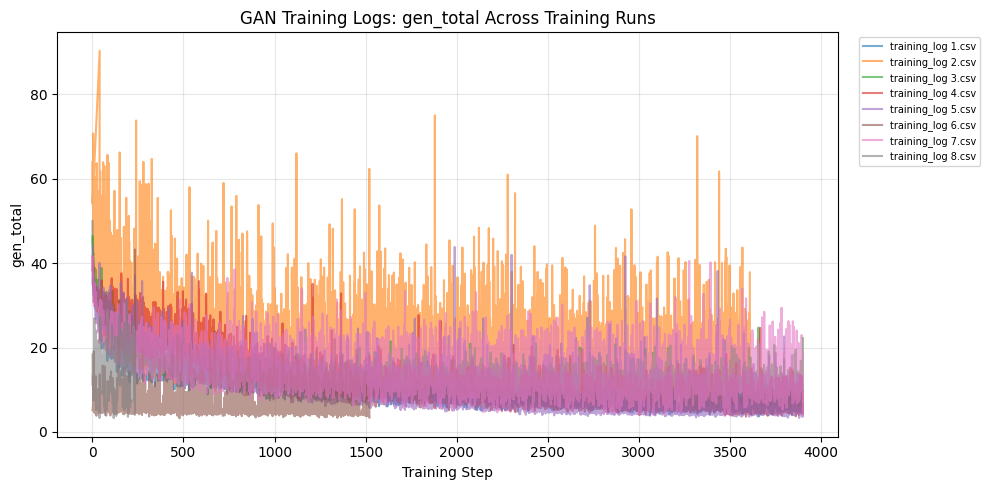


Figure saved:
/content/Final_Underwater_GAN_Project/figures/training_logs_gen_total.png


In [15]:
# ==========================================
# STEP 12: TRAINING LOG FIGURE
# ==========================================

import glob
import pandas as pd
import matplotlib.pyplot as plt

log_files = glob.glob(
    os.path.join(
        source_root,
        "training_log*.csv"
    )
)

all_training_logs = []

for file in sorted(log_files):

    temp = pd.read_csv(file)

    temp["source_file"] = os.path.basename(file)

    all_training_logs.append(temp)

training_logs_df = pd.concat(
    all_training_logs,
    ignore_index=True
)

print("Combined training-log shape:")
print(training_logs_df.shape)

print("\nAvailable columns:")
print(training_logs_df.columns.tolist())

# Plot generator loss
plt.figure(figsize=(10, 5))

for source in training_logs_df["source_file"].unique():

    temp = training_logs_df[
        training_logs_df["source_file"] == source
    ]

    plt.plot(
        temp["step"],
        temp["gen_total"],
        alpha=0.6,
        label=source
    )

plt.xlabel("Training Step")
plt.ylabel("gen_total")
plt.title("GAN Training Logs: gen_total Across Training Runs")
plt.grid(True, alpha=0.3)

# Keep legend readable
plt.legend(
    fontsize=7,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

training_log_figure = os.path.join(
    repo_dir,
    "figures",
    "training_logs_gen_total.png"
)

plt.savefig(
    training_log_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved:")
print(training_log_figure)

In [16]:
# ==========================================
# STEP 13: CREATE FINAL RESULTS TABLE
# ==========================================

# Summary of each available training run
run_summary = (
    training_logs_df
    .groupby("source_file")
    .agg(
        Total_Steps=("step", "max"),
        Minimum_gen_total=("gen_total", "min"),
        Maximum_gen_total=("gen_total", "max"),
        Mean_gen_total=("gen_total", "mean"),
        Final_gen_total=("gen_total", "last")
    )
    .reset_index()
)

# Round numeric values
numeric_columns = run_summary.select_dtypes(
    include=[np.number]
).columns

run_summary[numeric_columns] = (
    run_summary[numeric_columns].round(6)
)

print("FINAL TRAINING-RUN SUMMARY")
print("==========================")

display(run_summary)

# Save report-ready table
results_table_path = os.path.join(
    repo_dir,
    "results",
    "training_run_summary.csv"
)

run_summary.to_csv(
    results_table_path,
    index=False
)

print("\nSaved:")
print(results_table_path)

FINAL TRAINING-RUN SUMMARY


,source_file,Total_Steps,Minimum_gen_total,Maximum_gen_total,Mean_gen_total,Final_gen_total
0,training_log 1.csv,3900,3.706866,49.983898,9.662541,5.169765
1,training_log 2.csv,3609,5.643744,90.369987,21.523687,37.811237
2,training_log 3.csv,3900,5.297752,46.455120,13.378945,22.243809
3,training_log 4.csv,3900,3.638510,41.739376,12.278559,9.584647
4,training_log 5.csv,3900,3.336115,44.109241,10.858065,3.916015
5,training_log 6.csv,1521,3.235735,43.257217,6.453285,3.426349
6,training_log 7.csv,3900,3.784780,41.674061,15.464327,3.984801
7,training_log 8.csv,234,3.293583,31.013775,15.149645,4.112289



Saved:
/content/Final_Underwater_GAN_Project/results/training_run_summary.csv


In [17]:
# ==========================================
# STEP 14: CREATE PACKAGE MANIFEST
# ==========================================

manifest = []

for root, dirs, files_list in os.walk(repo_dir):

    for filename in files_list:

        full_path = os.path.join(root, filename)

        relative_path = os.path.relpath(
            full_path,
            repo_dir
        )

        file_size_kb = os.path.getsize(full_path) / 1024

        manifest.append({
            "File": relative_path,
            "Size_KB": round(file_size_kb, 2)
        })

manifest_df = pd.DataFrame(manifest)

manifest_df = manifest_df.sort_values(
    "File"
).reset_index(drop=True)

print("FINAL SOFTWARE PACKAGE CONTENTS")
print("================================")

display(manifest_df)

manifest_path = os.path.join(
    repo_dir,
    "docs",
    "package_manifest.csv"
)

manifest_df.to_csv(
    manifest_path,
    index=False
)

print("\nPackage manifest saved:")
print(manifest_path)

print("\nTotal files:", len(manifest_df))

FINAL SOFTWARE PACKAGE CONTENTS


,File,Size_KB
0,README.md,3.42
1,docs/source_data/dataset_README.md,0.07
2,docs/source_data/training_log 1.csv,240.90
3,docs/source_data/training_log 2.csv,228.15
4,docs/source_data/training_log 3.csv,242.57
5,docs/source_data/training_log 4.csv,241.12
6,docs/source_data/training_log 5.csv,241.18
7,docs/source_data/training_log 6.csv,93.09
8,docs/source_data/training_log 7.csv,241.99
9,docs/source_data/training_log 8.csv,14.64



Package manifest saved:
/content/Final_Underwater_GAN_Project/docs/package_manifest.csv

Total files: 14


# ==========================================
# STEP 15: CREATE FINAL REPORT DRAFT
# ==========================================

report = """FINAL PROJECT REPORT DRAFT

UNDERWATER IMAGE ENHANCEMENT USING GAN-BASED
TRAINING ANALYSIS AND TEMPORAL CONVOLUTIONAL NETWORK

1. ABSTRACT

This project focuses on the analysis and development of an underwater image
enhancement workflow using GAN-based training data and a temporal prediction
pipeline. The available dataset contains GAN training logs, including epoch,
step, generator-related loss (gen_total), discriminator loss (disc_loss), and
training time.

A Temporal Convolutional Network (TCN) was developed to model temporal
patterns in the available training-log data. Several TCN configurations were
compared and the tuned TCN (TCN-4) was selected based on validation
performance.

The project also includes preprocessing, leakage-aware data splitting,
model evaluation, error analysis, software packaging, documentation, and an
example inference workflow.


2. INTRODUCTION

Underwater images commonly suffer from visual degradation caused by
illumination variation, color distortion, low contrast, scattering, and
other environmental effects. GAN-based approaches can be used to improve
underwater image appearance.

This project investigates the available GAN training information and develops
a reproducible machine-learning pipeline around the recorded training logs.
The final pipeline demonstrates temporal prediction using a TCN model.


3. DATASET

The available archive contains:

- GAN training log CSV files
- Training checkpoint archives
- README documentation

The training logs contain the following main fields:

- epoch
- step
- gen_total
- disc_loss
- time_s

The current prediction target is gen_total.

Important limitation:
The available CSV files do not provide verified SoH/RUL labels or direct
image-quality ground truth.


4. DATA PREPROCESSING

The final pipeline uses the following input features:

- epoch
- step
- disc_loss
- time_s

The target is:

- gen_total

A sequence length of 10 time steps is used.

The data is divided using a time-ordered split:

- Training: 70%
- Validation: 15%
- Testing: 15%

StandardScaler is fitted using training data only and then applied to the
validation and test sets.


5. MODEL DEVELOPMENT

The final selected architecture is a tuned Temporal Convolutional Network
(TCN-4).

The network contains:

- 1D convolution layer with 64 channels
- ReLU activation
- Dilated convolution layer with dilation 2
- ReLU activation
- Dilated convolution layer with dilation 4
- ReLU activation
- Fully connected output layer

The final configuration uses:

- Hidden channels: 64
- Dropout: 0.0
- Learning rate: 0.0005
- Batch size: 32
- Epochs: 15
- Optimizer: Adam
- Loss: MSELoss
- Random seed: 42


6. MODEL SELECTION

Multiple TCN configurations were evaluated.

The best validation result was obtained by TCN-4 with a validation loss of
approximately 22.04 in the model-selection experiment.

The selected model contains approximately 19,393 trainable parameters.

The model was selected using validation performance while maintaining the
same general data and evaluation methodology.


7. ERROR AND FAILURE ANALYSIS

Detailed error analysis was performed on the held-out test predictions.

The analysis includes:

- MAE
- RMSE
- MAPE
- R2
- 95th percentile absolute error
- Maximum absolute error
- Worst prediction cases
- Source-file error analysis
- Target-range error analysis
- Permutation feature importance
- Error-feature correlation
- Actual versus predicted visualization

The largest prediction errors were separately identified and saved for
inspection.


8. SOFTWARE PACKAGE

The final software repository is organized into the following components:

model/
Contains the trained model artifact when available.

preprocessing/
Contains preprocessing configuration and scaler artifacts.

inference/
Contains an example inference script.

outputs/
Contains prediction outputs when available.

results/
Contains evaluation metrics, training results, and summary tables.

figures/
Contains final visualizations.

error_analysis/
Contains detailed error-analysis outputs.

docs/
Contains documentation, source information, and package metadata.

README.md
Contains setup and execution instructions.


9. INFERENCE WORKFLOW

The example inference workflow follows:

Input sequence
      |
      v
Feature preprocessing
      |
      v
Training-fitted scaler
      |
      v
Trained TCN model
      |
      v
Predicted gen_total


10. RESULTS

The final package includes the available numerical results and training-log
summaries.

The repository also contains:

- Final prediction outputs when available
- Error-analysis tables
- Training-log visualization
- Source-run summary
- Feature-importance results
- Limitation list


11. LIMITATIONS

The following limitations must be considered:

1. The prediction target is gen_total, not SoH or RUL.

2. The available data consists mainly of GAN training logs rather than direct
   image-quality ground truth.

3. Physical cell IDs and verified degradation-stage labels are not available.

4. Some globally constructed sequences may cross source-file boundaries.

5. source_file is a training-run/source identifier and not a physical cell ID.

6. Target-range groups are statistical ranges and should not be interpreted
   as verified degradation stages.

7. Permutation feature importance indicates predictive dependence and does
   not establish causality.

8. Current failure analysis is primarily log-level rather than image-level.

9. Image-quality metrics such as PSNR, SSIM, UIQM, and UCIQE are not verified
   in the current training-log dataset.

10. Final mentor corrections and approval remain pending.


12. FUTURE WORK

Future improvements can include:

- Preventing sequences from crossing source-file boundaries.
- Obtaining verified image-quality ground-truth measurements.
- Evaluating enhanced images using PSNR, SSIM, UIQM, and UCIQE where
  appropriate.
- Testing the model on completely unseen training runs.
- Establishing verified degradation-stage or physical-unit identifiers.
- Improving the inference interface.
- Performing mentor-approved final validation.


13. CONCLUSION

The project developed a reproducible software and analysis workflow for the
available underwater GAN training-log data. The tuned TCN provided a temporal
prediction model for gen_total, while the error-analysis stage identified
important failure cases and documented methodological limitations.

The final software package provides preprocessing configuration, model
artifacts where available, inference code, results, visualizations,
error-analysis outputs, and documentation.

The package is suitable as a final project draft subject to mentor review,
correction, and approval.
"""

report_path = os.path.join(
    repo_dir,
    "docs",
    "Final_Project_Report_Draft.txt"
)

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report)

print("Final report draft created successfully.")
print(report_path)

print("\nReport sections:")
for line in report.splitlines():
    if line and line[0].isdigit() and "." in line[:4]:
        print(line)